# 1. Converting 1024d to 2d 

In [1]:
import numpy as np
from sklearn.decomposition import TruncatedSVD
from tqdm import tqdm

# ============================================================
# Paths
# ============================================================
INPUT_FILE = r"E:\Projects\CheckThat 2026\my data\merged data embeddings\new_data_dense_embeddings.npz"

OUTPUT_FILE = r"E:\Projects\CheckThat 2026\my data\2d_svd_embeddings.npz"

# ============================================================
# Load embeddings
# ============================================================
print("Loading embeddings...")

data = np.load(INPUT_FILE, allow_pickle=True)

keys = data.files

print(f"Found {len(keys)} claims")

# ============================================================
# Collect all embeddings
# ============================================================
all_embeddings = []
claim_shapes = {}

for key in tqdm(keys, desc="Reading claims"):
    
    emb = data[key]

    # Expected shape:
    # (21,1024) or (16,1024)
    claim_shapes[key] = emb.shape[0]

    all_embeddings.append(emb)

all_embeddings = np.vstack(all_embeddings)

print("\nCombined embedding matrix:")
print(all_embeddings.shape)

# ============================================================
# SVD -> 2 Dimensions
# ============================================================
print("\nRunning Truncated SVD...")

svd = TruncatedSVD(
    n_components=2,
    random_state=42
)

all_embeddings_2d = svd.fit_transform(all_embeddings)

print("Done.")

print(
    f"Explained Variance Ratio = "
    f"{svd.explained_variance_ratio_.sum():.4f}"
)

# ============================================================
# Split back into claim structure
# ============================================================
result = {}

start = 0

for key in keys:

    count = claim_shapes[key]

    result[key] = all_embeddings_2d[start:start + count]

    start += count

# ============================================================
# Save
# ============================================================
np.savez_compressed(
    OUTPUT_FILE,
    **result
)

print(f"\nSaved 2D embeddings to:\n{OUTPUT_FILE}")

# ============================================================
# Verification
# ============================================================
sample_key = keys[0]

print("\nExample:")
print("Original shape :", data[sample_key].shape)
print("2D shape       :", result[sample_key].shape)

Loading embeddings...
Found 6469 claims


Reading claims: 100%|██████████| 6469/6469 [00:10<00:00, 615.48it/s]



Combined embedding matrix:
(134554, 1024)

Running Truncated SVD...
Done.
Explained Variance Ratio = 0.0652

Saved 2D embeddings to:
E:\Projects\CheckThat 2026\my data\2d_svd_embeddings.npz

Example:
Original shape : (21, 1024)
2D shape       : (21, 2)


# 2. Class Separation Analysis using 2D SVD Embeddings

Visualize all claim and reasoning-trace embeddings in the 2D SVD space and color them according to their veracity class (True, False, Conflicting) to evaluate semantic separability between classes.

Total embeddings plotted: 133,981
Missing claims: 28
Labels found: ['Conflicting', 'False', 'True']


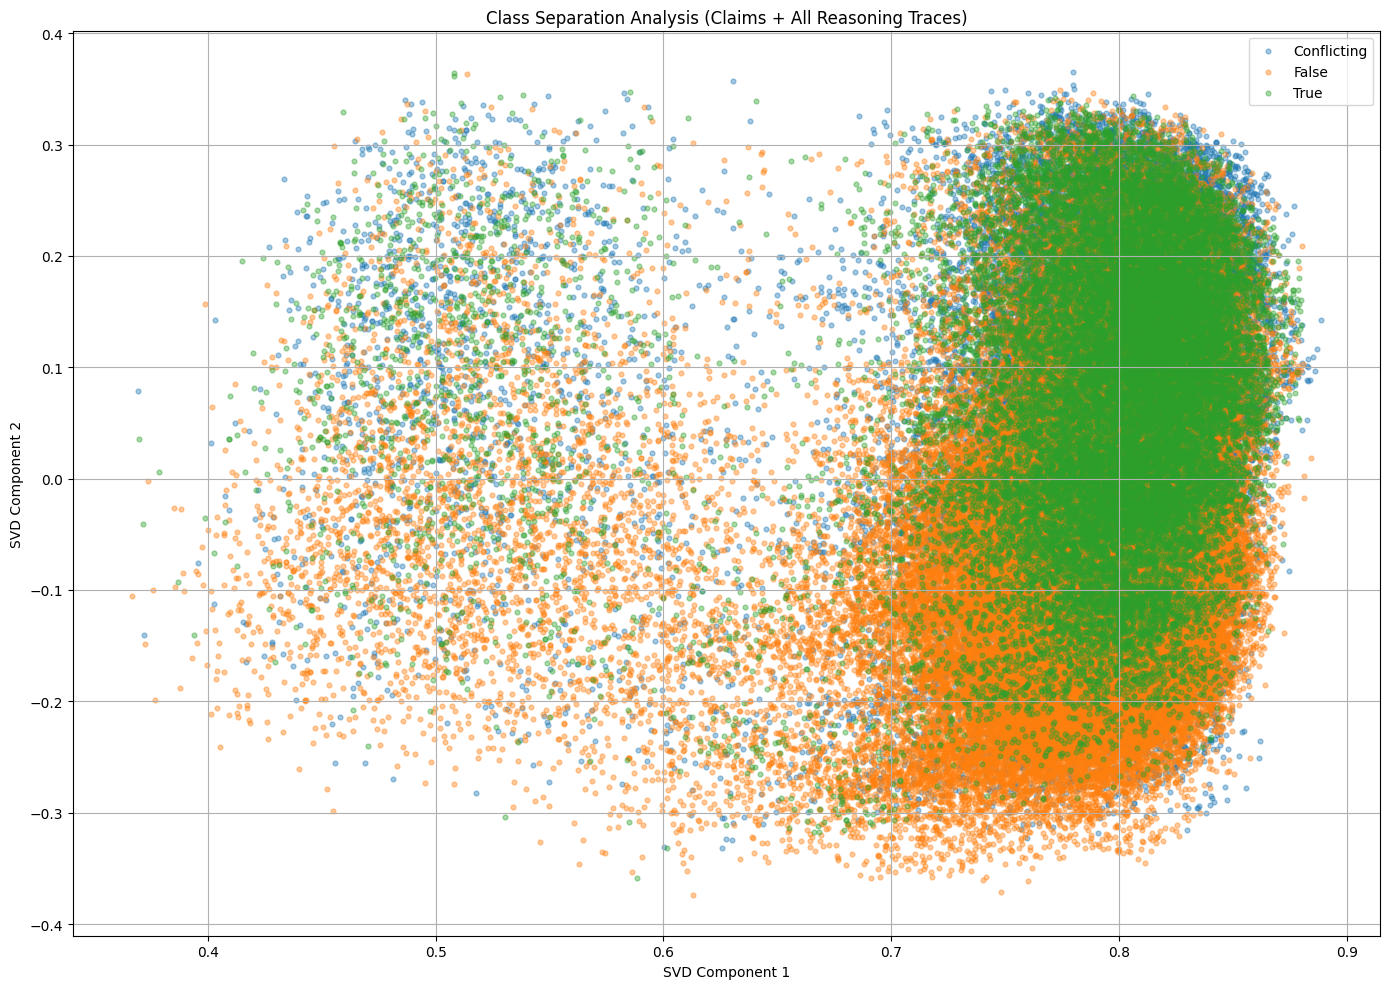

In [16]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FILE PATHS
# ============================================================

EMBEDDING_FILE = r"E:\Projects\CheckThat 2026\my data\2d_svd_embeddings.npz"

SEMANTIC_MATCHES = r"E:\Projects\CheckThat 2026\my data\semantic_matches.json"

TRAIN_FILE = r"E:\Projects\CheckThat 2026\task 2\data\train.json"
VALID_FILE = r"E:\Projects\CheckThat 2026\task 2\data\validation.json"
TEST_FILE = r"E:\Projects\CheckThat 2026\task 2\data\test.json"

# ============================================================
# LOAD FILES
# ============================================================

with open(SEMANTIC_MATCHES, "r", encoding="utf-8") as f:
    semantic_matches = json.load(f)

with open(TRAIN_FILE, "r", encoding="utf-8") as f:
    train_data = json.load(f)

with open(VALID_FILE, "r", encoding="utf-8") as f:
    valid_data = json.load(f)

with open(TEST_FILE, "r", encoding="utf-8") as f:
    test_data = json.load(f)

all_claims = train_data + valid_data + test_data

svd_embeddings = np.load(EMBEDDING_FILE, allow_pickle=True)

# ============================================================
# LOOKUP TABLES
# ============================================================

newid_to_claim = {}

for item in semantic_matches:
    newid_to_claim[item["new_id"]] = item["new_claim"]

claim_to_label = {}

# for item in all_claims:

#     claim_text = item.get("claim", "").strip()

#     label = str(item.get("label", "unknown")).strip().lower()

#     claim_to_label[claim_text] = label

for item in all_claims:

    claim_text = item.get("claim", "").strip()

    label = str(
        item.get("Label",
                 item.get("label", "unknown"))
    ).strip()

    claim_to_label[claim_text] = label

# ============================================================
# COLLECT ALL EMBEDDINGS
# ============================================================

all_points = []
all_labels = []

missing_claims = 0

for key in svd_embeddings.files:

    claim_id = int(key.split("_")[-1])

    if claim_id not in newid_to_claim:
        continue

    claim_text = newid_to_claim[claim_id]

    if claim_text not in claim_to_label:
        missing_claims += 1
        continue

    label = claim_to_label[claim_text]

    embeddings = svd_embeddings[key]

    # Include claim embedding + all traces
    for emb in embeddings:

        all_points.append(emb)
        all_labels.append(label)

all_points = np.array(all_points)

print(f"Total embeddings plotted: {len(all_points):,}")
print(f"Missing claims: {missing_claims}")
print("Labels found:", sorted(set(all_labels)))

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(14, 10))

unique_labels = sorted(set(all_labels))

for lbl in unique_labels:

    idx = [i for i, x in enumerate(all_labels) if x == lbl]

    plt.scatter(
        all_points[idx, 0],
        all_points[idx, 1],
        alpha=0.4,
        s=12,
        label=lbl
    )

plt.title("Class Separation Analysis (Claims + All Reasoning Traces)")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 3. Claim Centroid Analysis 
(in Original 1024-Dimensional Embedding Space)

### Objective
Compute a semantic centroid for each claim using its claim embedding and all associated reasoning trace embeddings, then measure how far the original claim embedding lies from the centroid.

Total Claims Analysed: 6,441

Distance from Claim Embedding to Claim Centroid



,count,mean,median,std,min,max
label,,,,,,
conflicting,1514,0.5900,0.5972,0.0780,0.3661,0.8601
false,3740,0.5682,0.5716,0.0855,0.3050,0.9652
true,1187,0.5964,0.6037,0.0756,0.2615,0.8596


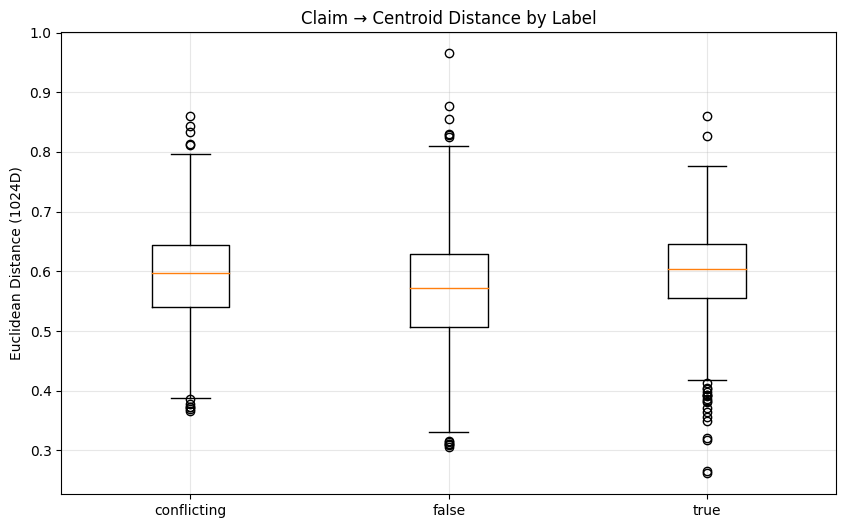

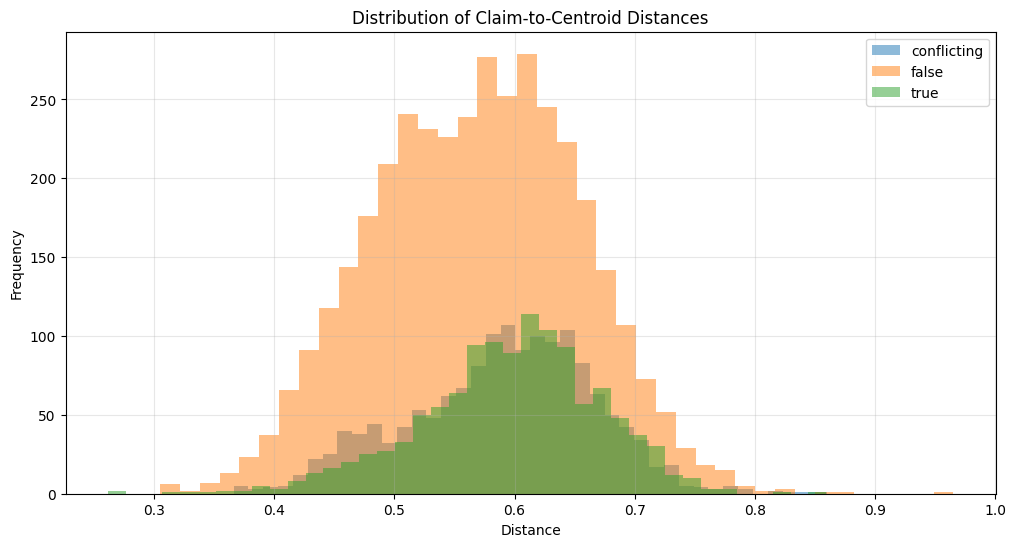


Top 10 Claims Farthest From Their Centroid



,claim_id,label,distance_to_centroid,num_embeddings
3655,3673,false,0.965245,21
3061,3076,false,0.876417,21
768,769,conflicting,0.860147,21
5190,5212,true,0.859595,21
4767,4787,false,0.855102,21
1405,1408,conflicting,0.843738,21
808,809,conflicting,0.833655,21
4626,4646,false,0.829681,21
2975,2990,false,0.827867,21
5713,5737,true,0.826709,21


In [20]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FILE PATHS
# ============================================================

EMBEDDING_FILE = r"E:\Projects\CheckThat 2026\my data\merged data embeddings\new_data_dense_embeddings.npz"

SEMANTIC_MATCHES = r"E:\Projects\CheckThat 2026\my data\semantic_matches.json"

TRAIN_FILE = r"E:\Projects\CheckThat 2026\task 2\data\train.json"
VALID_FILE = r"E:\Projects\CheckThat 2026\task 2\data\validation.json"
TEST_FILE = r"E:\Projects\CheckThat 2026\task 2\data\test.json"

# ============================================================
# LOAD DATA
# ============================================================

with open(SEMANTIC_MATCHES, "r", encoding="utf-8") as f:
    semantic_matches = json.load(f)

with open(TRAIN_FILE, "r", encoding="utf-8") as f:
    train_data = json.load(f)

with open(VALID_FILE, "r", encoding="utf-8") as f:
    valid_data = json.load(f)

with open(TEST_FILE, "r", encoding="utf-8") as f:
    test_data = json.load(f)

all_claims = train_data + valid_data + test_data

embeddings = np.load(EMBEDDING_FILE, allow_pickle=True)

# ============================================================
# LOOKUPS
# ============================================================

newid_to_claim = {
    item["new_id"]: item["new_claim"]
    for item in semantic_matches
}

claim_to_label = {}

for item in all_claims:

    claim_text = item.get("claim", "").strip()

    label = str(
        item.get("Label",
                 item.get("label", "unknown"))
    ).strip().lower()

    claim_to_label[claim_text] = label

# ============================================================
# CENTROID ANALYSIS
# ============================================================

results = []

for key in embeddings.files:

    claim_id = int(key.split("_")[-1])

    if claim_id not in newid_to_claim:
        continue

    claim_text = newid_to_claim[claim_id]

    if claim_text not in claim_to_label:
        continue

    label = claim_to_label[claim_text]

    emb_matrix = embeddings[key]

    # --------------------------------------------------------
    # Claim embedding
    # --------------------------------------------------------

    claim_embedding = emb_matrix[0]

    # --------------------------------------------------------
    # Claim centroid
    # --------------------------------------------------------

    centroid = np.mean(emb_matrix, axis=0)

    # --------------------------------------------------------
    # Distance claim -> centroid
    # --------------------------------------------------------

    distance = np.linalg.norm(
        claim_embedding - centroid
    )

    results.append({
        "claim_id": claim_id,
        "label": label,
        "distance_to_centroid": distance,
        "num_embeddings": len(emb_matrix)
    })

# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(results)

print(f"Total Claims Analysed: {len(df):,}")

# ============================================================
# SUMMARY STATISTICS
# ============================================================

summary = (
    df.groupby("label")["distance_to_centroid"]
      .agg([
          "count",
          "mean",
          "median",
          "std",
          "min",
          "max"
      ])
      .round(4)
)

print("\nDistance from Claim Embedding to Claim Centroid\n")
display(summary)

# ============================================================
# BOXPLOT
# ============================================================

plt.figure(figsize=(10, 6))

labels = sorted(df["label"].unique())

data = [
    df[df["label"] == lbl]["distance_to_centroid"]
    for lbl in labels
]

# plt.boxplot(
#     data,
#     labels=labels
# )

box = plt.boxplot(data)

plt.xticks(
    range(1, len(labels) + 1),
    labels
)

plt.title(
    "Claim → Centroid Distance by Label"
)

plt.ylabel(
    "Euclidean Distance (1024D)"
)

plt.grid(True, alpha=0.3)

plt.show()

# ============================================================
# HISTOGRAMS
# ============================================================

plt.figure(figsize=(12, 6))

for lbl in labels:

    subset = df[df["label"] == lbl]

    plt.hist(
        subset["distance_to_centroid"],
        bins=40,
        alpha=0.5,
        label=lbl
    )

plt.title(
    "Distribution of Claim-to-Centroid Distances"
)

plt.xlabel("Distance")
plt.ylabel("Frequency")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# ============================================================
# TOP 10 FARTHEST CLAIMS
# ============================================================

print("\nTop 10 Claims Farthest From Their Centroid\n")

display(
    df.sort_values(
        "distance_to_centroid",
        ascending=False
    ).head(10)
)

# Trajectory Analysis of Reasoning Traces in 2D SVD Space

### Objective
Model each claim and its reasoning traces as a semantic trajectory:

Claim → Trace1 → Trace2 → ... → TraceN

and compute trajectory characteristics for different veracity labels.

### Metrics

1. Path Length
2. Drift
3. Straightness Ratio
4. Mean Turning Angle (Curvature)
5. Maximum Turning Angle
6. Trajectory Efficiency

Claims analysed: 6,441


path_length           drift         straightness          \
                   mean  median    mean  median         mean  median   
label                                                                  
conflicting      0.8001  0.7791  0.2715  0.2788       0.3480  0.3548   
false            0.7886  0.7720  0.2527  0.2571       0.3308  0.3318   
true             0.7976  0.7830  0.2820  0.2876       0.3646  0.3694   

            mean_curvature           max_curvature           efficiency  \
                      mean    median          mean    median       mean   
label                                                                     
conflicting       118.5391  118.9585      176.5788  177.6476     0.0084   
false             118.4107  118.3857      176.5795  177.6338     0.0084   
true              118.6714  118.7271      176.7621  177.7579     0.0084   

                     
             median  
label                
conflicting  0.0083  
false        0.0084  
true         0.0084

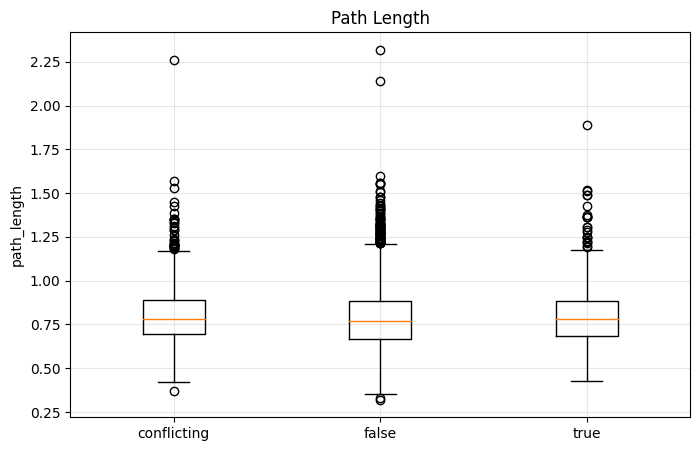

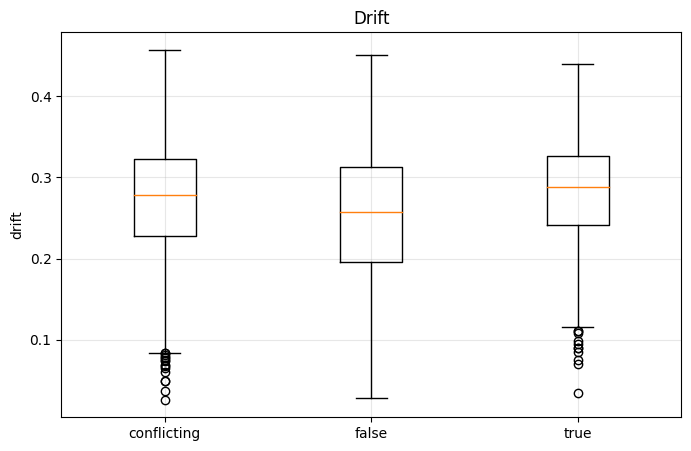

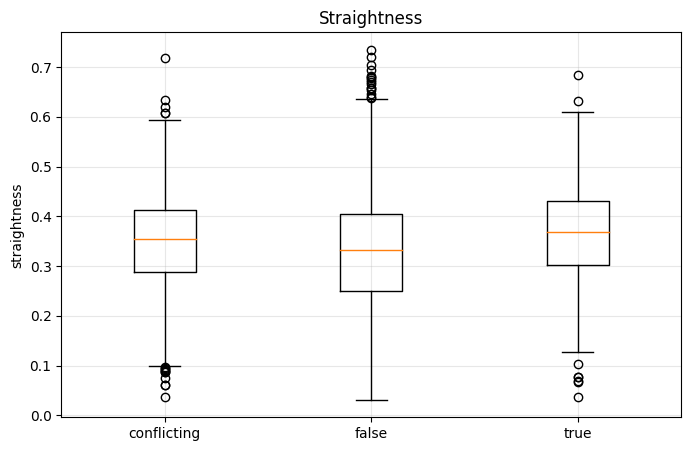

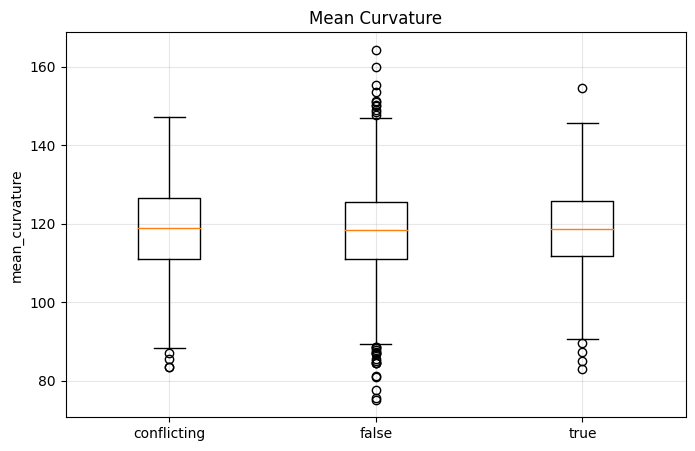

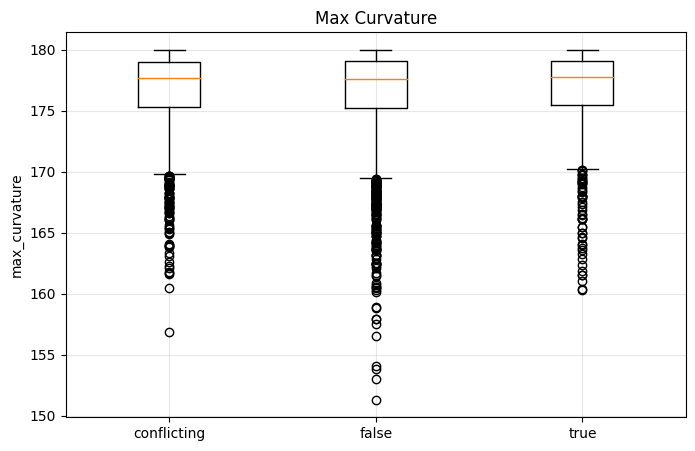

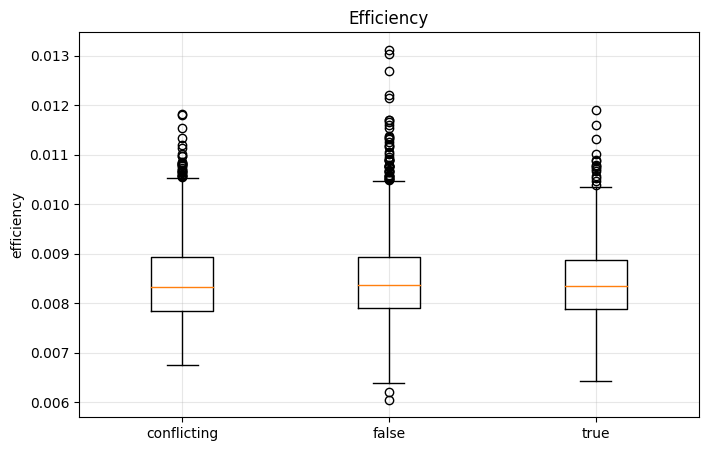

In [21]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FILE PATHS
# ============================================================

EMBEDDING_FILE = r"E:\Projects\CheckThat 2026\my data\2d_svd_embeddings.npz"

SEMANTIC_MATCHES = r"E:\Projects\CheckThat 2026\my data\semantic_matches.json"

TRAIN_FILE = r"E:\Projects\CheckThat 2026\task 2\data\train.json"
VALID_FILE = r"E:\Projects\CheckThat 2026\task 2\data\validation.json"
TEST_FILE = r"E:\Projects\CheckThat 2026\task 2\data\test.json"

# ============================================================
# LOAD DATA
# ============================================================

with open(SEMANTIC_MATCHES, "r", encoding="utf-8") as f:
    semantic_matches = json.load(f)

with open(TRAIN_FILE, "r", encoding="utf-8") as f:
    train_data = json.load(f)

with open(VALID_FILE, "r", encoding="utf-8") as f:
    valid_data = json.load(f)

with open(TEST_FILE, "r", encoding="utf-8") as f:
    test_data = json.load(f)

all_claims = train_data + valid_data + test_data

embeddings = np.load(EMBEDDING_FILE, allow_pickle=True)

# ============================================================
# LOOKUPS
# ============================================================

newid_to_claim = {
    item["new_id"]: item["new_claim"]
    for item in semantic_matches
}

claim_to_label = {}

for item in all_claims:

    claim_text = item.get("claim", "").strip()

    label = str(
        item.get(
            "Label",
            item.get("label", "unknown")
        )
    ).strip().lower()

    claim_to_label[claim_text] = label

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def euclidean(a, b):
    return np.linalg.norm(a - b)

def turning_angle(a, b, c):

    v1 = b - a
    v2 = c - b

    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)

    if norm1 == 0 or norm2 == 0:
        return 0

    cosine = np.dot(v1, v2) / (norm1 * norm2)

    cosine = np.clip(cosine, -1, 1)

    angle = np.degrees(np.arccos(cosine))

    return angle

# ============================================================
# TRAJECTORY ANALYSIS
# ============================================================

results = []

for key in embeddings.files:

    claim_id = int(key.split("_")[-1])

    if claim_id not in newid_to_claim:
        continue

    claim_text = newid_to_claim[claim_id]

    if claim_text not in claim_to_label:
        continue

    label = claim_to_label[claim_text]

    points = embeddings[key]

    if len(points) < 3:
        continue

    # --------------------------------------------------------
    # Path Length
    # --------------------------------------------------------

    path_length = 0

    for i in range(len(points) - 1):

        path_length += euclidean(
            points[i],
            points[i + 1]
        )

    # --------------------------------------------------------
    # Drift
    # --------------------------------------------------------

    drift = euclidean(
        points[0],
        points[-1]
    )

    # --------------------------------------------------------
    # Straightness
    # --------------------------------------------------------

    if path_length > 0:
        straightness = drift / path_length
    else:
        straightness = 0

    # --------------------------------------------------------
    # Curvature
    # --------------------------------------------------------

    angles = []

    for i in range(1, len(points) - 1):

        angle = turning_angle(
            points[i - 1],
            points[i],
            points[i + 1]
        )

        angles.append(angle)

    mean_curvature = np.mean(angles)

    max_curvature = np.max(angles)

    efficiency = 1 / (1 + mean_curvature)

    # --------------------------------------------------------

    results.append({
        "claim_id": claim_id,
        "label": label,
        "path_length": path_length,
        "drift": drift,
        "straightness": straightness,
        "mean_curvature": mean_curvature,
        "max_curvature": max_curvature,
        "efficiency": efficiency
    })

# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(results)

print(f"Claims analysed: {len(df):,}")

# ============================================================
# SUMMARY TABLE
# ============================================================

summary = (
    df.groupby("label")
      .agg({
          "path_length": ["mean", "median"],
          "drift": ["mean", "median"],
          "straightness": ["mean", "median"],
          "mean_curvature": ["mean", "median"],
          "max_curvature": ["mean", "median"],
          "efficiency": ["mean", "median"]
      })
      .round(4)
)

display(summary)

# ============================================================
# VISUALISATIONS
# ============================================================

metrics = [
    "path_length",
    "drift",
    "straightness",
    "mean_curvature",
    "max_curvature",
    "efficiency"
]

for metric in metrics:

    plt.figure(figsize=(8, 5))

    groups = []

    labels = sorted(df["label"].unique())

    for lbl in labels:
        groups.append(
            df[df["label"] == lbl][metric]
        )

    plt.boxplot(groups, labels=labels)

    plt.title(metric.replace("_", " ").title())

    plt.ylabel(metric)

    plt.grid(True, alpha=0.3)

    plt.show()

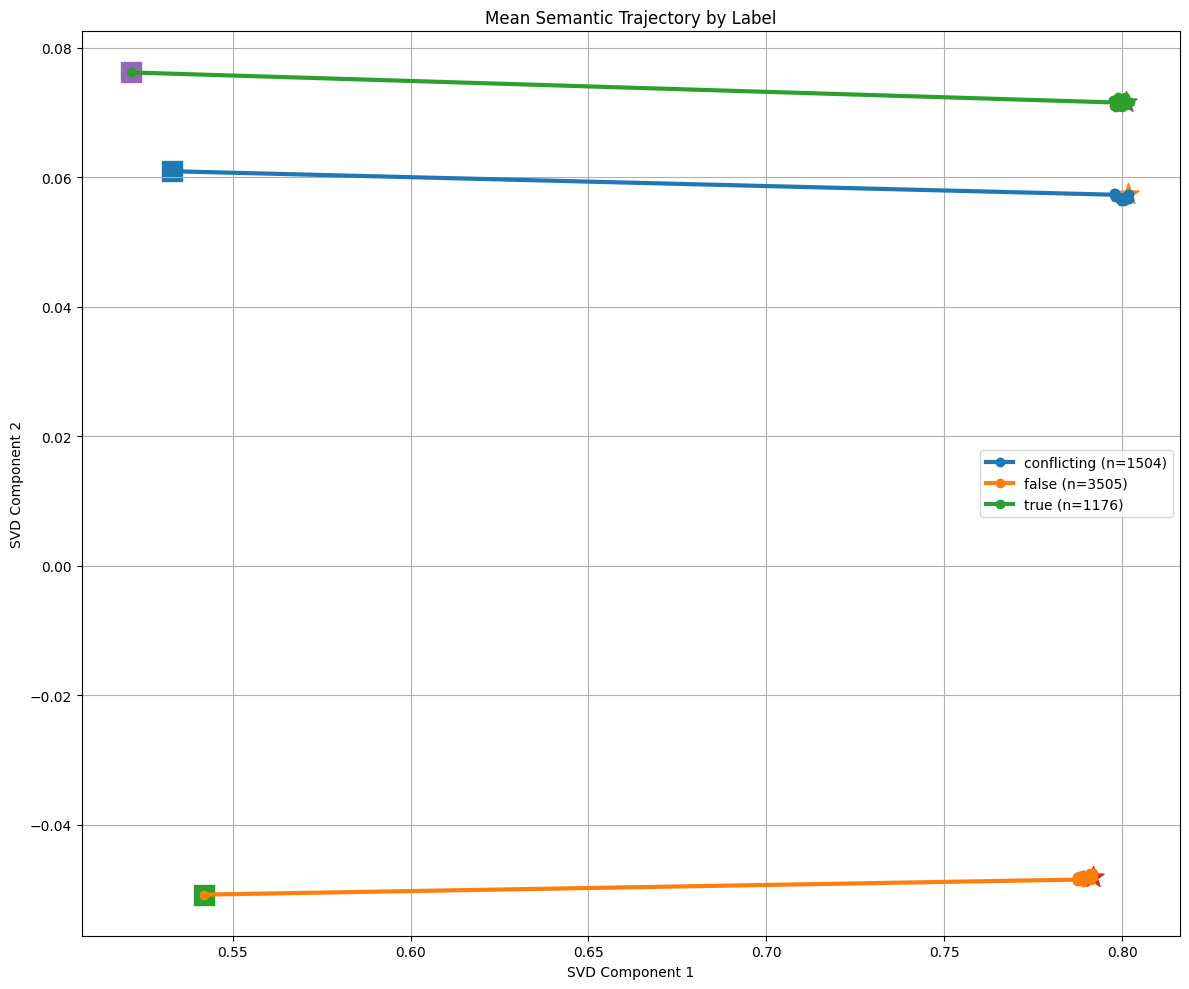

In [22]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FILE PATHS
# ============================================================

EMBEDDING_FILE = r"E:\Projects\CheckThat 2026\my data\2d_svd_embeddings.npz"

SEMANTIC_MATCHES = r"E:\Projects\CheckThat 2026\my data\semantic_matches.json"

TRAIN_FILE = r"E:\Projects\CheckThat 2026\task 2\data\train.json"
VALID_FILE = r"E:\Projects\CheckThat 2026\task 2\data\validation.json"
TEST_FILE = r"E:\Projects\CheckThat 2026\task 2\data\test.json"

# ============================================================
# LOAD DATA
# ============================================================

with open(SEMANTIC_MATCHES, "r", encoding="utf-8") as f:
    semantic_matches = json.load(f)

with open(TRAIN_FILE, "r", encoding="utf-8") as f:
    train_data = json.load(f)

with open(VALID_FILE, "r", encoding="utf-8") as f:
    valid_data = json.load(f)

with open(TEST_FILE, "r", encoding="utf-8") as f:
    test_data = json.load(f)

all_claims = train_data + valid_data + test_data

embeddings = np.load(EMBEDDING_FILE, allow_pickle=True)

# ============================================================
# LOOKUPS
# ============================================================

newid_to_claim = {
    item["new_id"]: item["new_claim"]
    for item in semantic_matches
}

claim_to_label = {}

for item in all_claims:

    claim_text = item.get("claim", "").strip()

    label = str(
        item.get(
            "Label",
            item.get("label", "unknown")
        )
    ).strip().lower()

    claim_to_label[claim_text] = label

# ============================================================
# COLLECT TRAJECTORIES
# ============================================================

label_trajectories = {}

for key in embeddings.files:

    claim_id = int(key.split("_")[-1])

    if claim_id not in newid_to_claim:
        continue

    claim_text = newid_to_claim[claim_id]

    if claim_text not in claim_to_label:
        continue

    label = claim_to_label[claim_text]

    traj = embeddings[key]

    # only keep claims with same length
    # expected:
    # 21 points = claim + 20 traces
    # 16 points = claim + 15 traces

    label_trajectories.setdefault(label, []).append(traj)

# ============================================================
# MEAN TRAJECTORY PER LABEL
# ============================================================

plt.figure(figsize=(12, 10))

for label, trajectories in label_trajectories.items():

    # group by trajectory length
    lengths = [len(t) for t in trajectories]

    most_common_length = max(
        set(lengths),
        key=lengths.count
    )

    selected = [
        t for t in trajectories
        if len(t) == most_common_length
    ]

    selected = np.stack(selected)

    # shape:
    # (num_claims, num_steps, 2)

    mean_traj = selected.mean(axis=0)

    plt.plot(
        mean_traj[:, 0],
        mean_traj[:, 1],
        marker="o",
        linewidth=3,
        label=f"{label} (n={len(selected)})"
    )

    # Mark start point

    plt.scatter(
        mean_traj[0, 0],
        mean_traj[0, 1],
        s=200,
        marker="s"
    )

    # Mark end point

    plt.scatter(
        mean_traj[-1, 0],
        mean_traj[-1, 1],
        s=250,
        marker="*"
    )

# ============================================================
# PLOT SETTINGS
# ============================================================

plt.title(
    "Mean Semantic Trajectory by Label"
)

plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

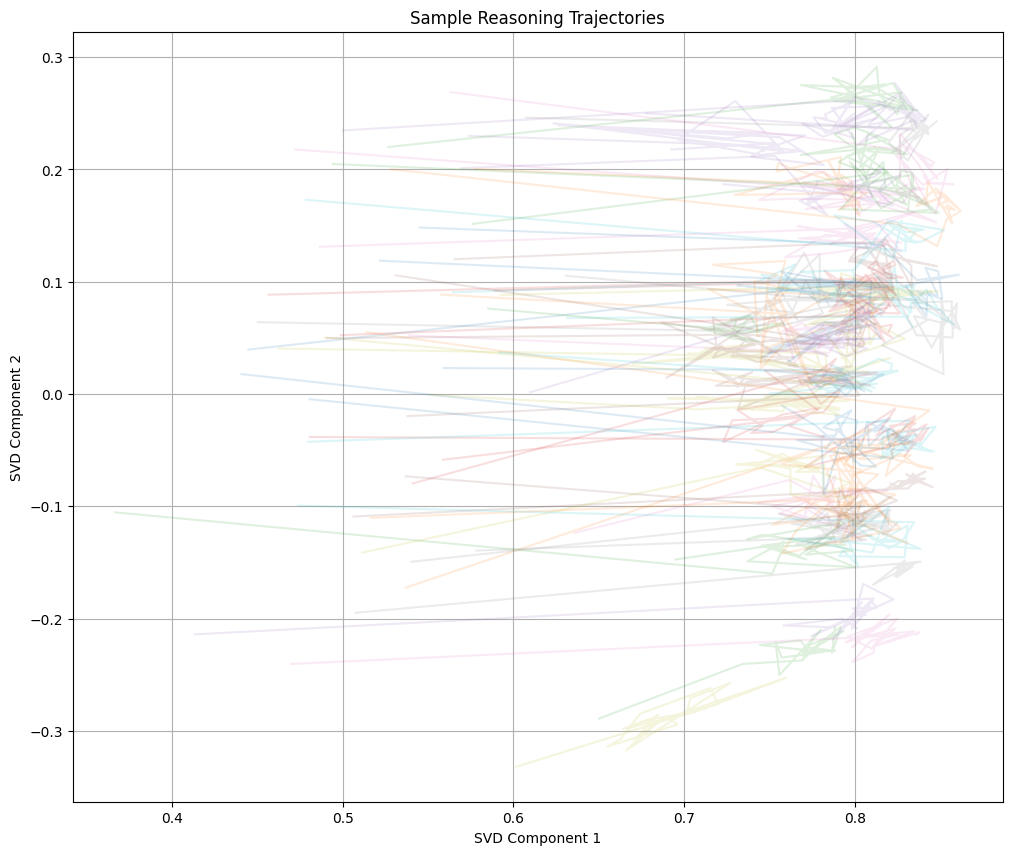

In [ ]:
plt.figure(figsize=(12, 10))

for label, trajectories in label_trajectories.items():

    sample_size = min(20, len(trajectories))

    idx = np.random.choice(
        len(trajectories),
        sample_size,
        replace=False
    )
    for i in idx:

        traj = trajectories[i]

        plt.plot(
            traj[:,0],
            traj[:,1],
            alpha=0.15
        )

plt.title(
    "Sample Reasoning Trajectories"
)

plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")

plt.grid(True)

plt.show()